{'III_HF          ': array([690, 687, 698, ...,   0,   0,   0], shape=(28100000,), dtype=int16),
 'III_LF          ': array([-359, -367, -369, ...,    0,    0,    0],
      shape=(28100000,), dtype=int16),
 'II_HF           ': array([185, 195, 185, ...,   0,   0,   0], shape=(28100000,), dtype=int16),
 'II_LF           ': array([116, 115, 121, ...,   0,   0,   0], shape=(28100000,), dtype=int16),
 'I_HF            ': array([348, 366, 341, ...,   0,   0,   0], shape=(28100000,), dtype=int16),
 'I_LF            ': array([-592, -587, -576, ...,    0,    0,    0],
      shape=(28100000,), dtype=int16)}
anot
{1688.0: 'Ishemia', 3600.0: 'Reperfusion'}

max=2.623704952121048
Длительность,с
4496.0
{1688.0: 'Ishemia', 3600.0: 'Reperfusion'}
Средняя длительность,с
0.3714568421052632

Медиана длительность,с
0.14839999999999964

Средняя частота,Гц
2.6551724137931036

Пульс
159.31034482758622

Количество кардиоциклов =77
(1000,)
Длительность=0.16
Отношение 0.03375707727801186
{'fQRS_ms': 28.96, 'RM

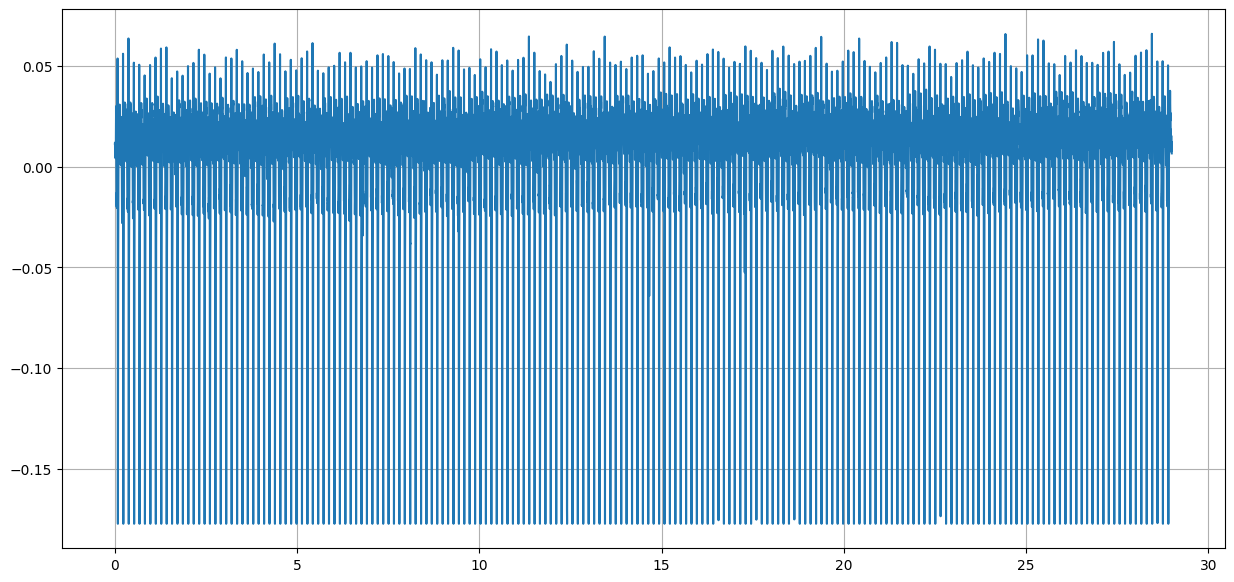

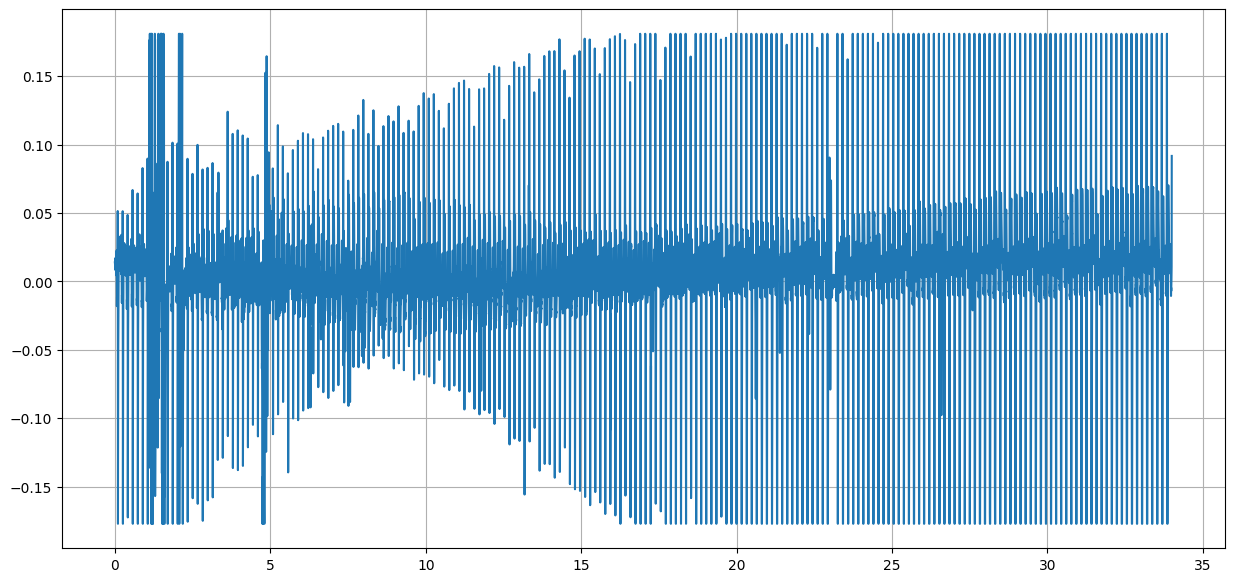

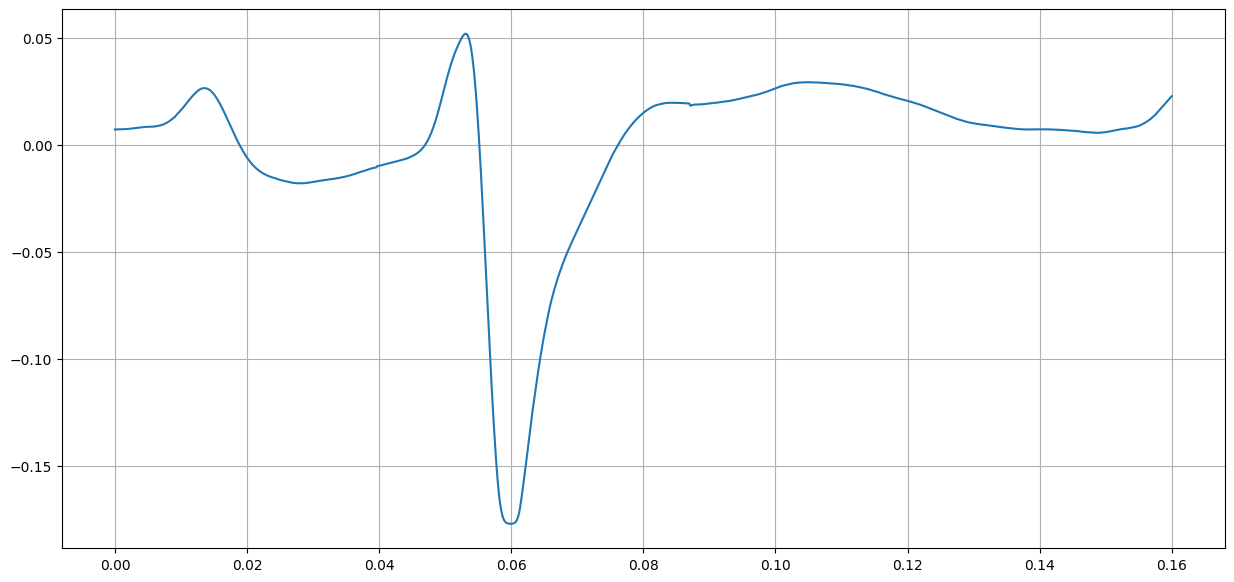

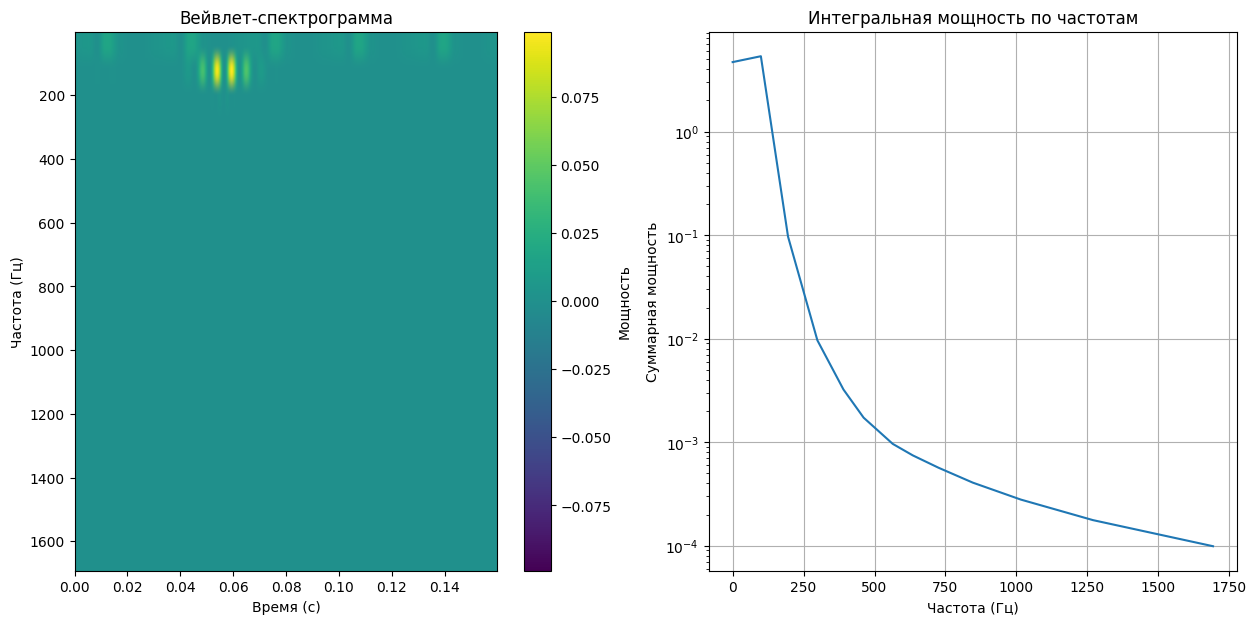

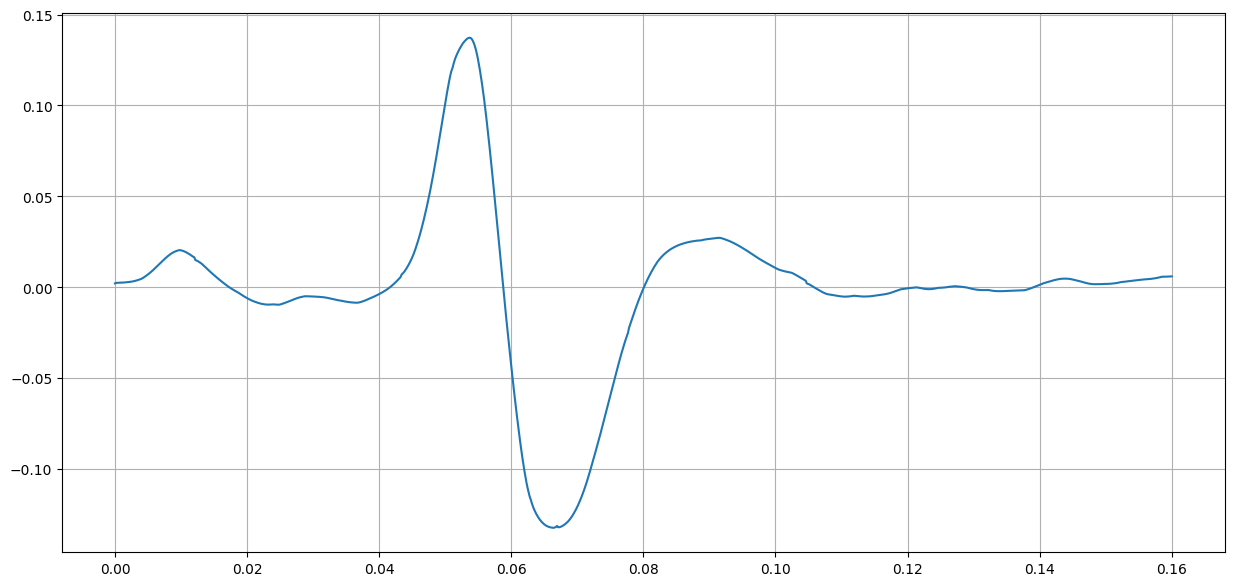

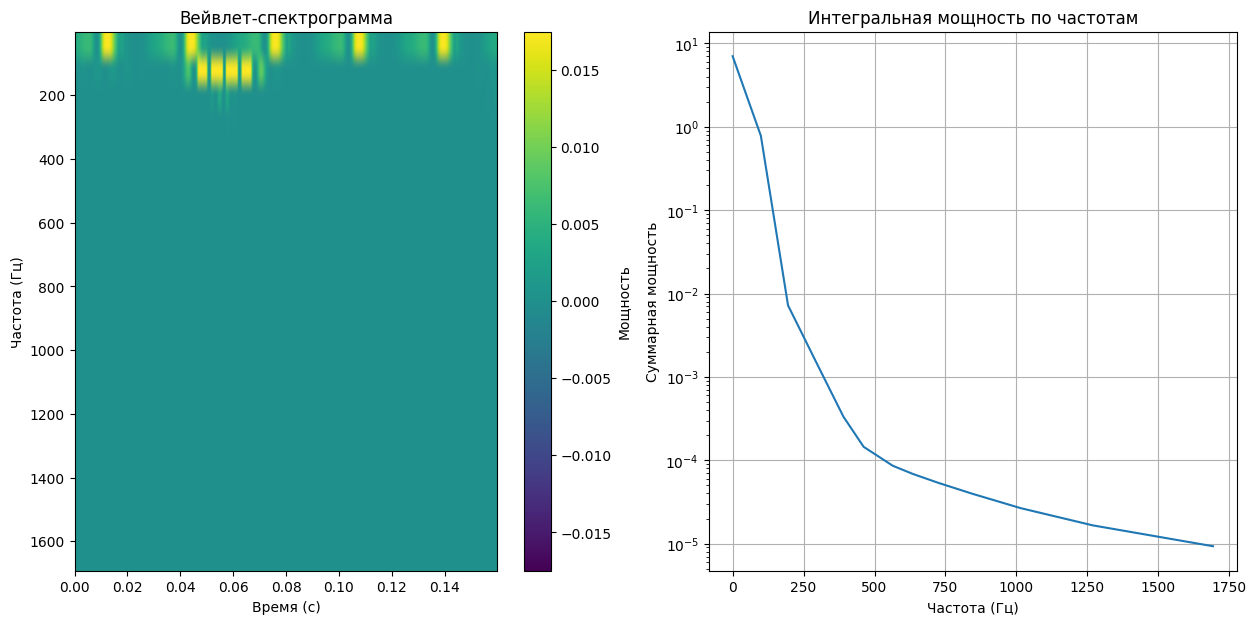

In [5]:
from  time_slice import time_slice
from read_edf import read_edf
from findpeaks import findpeaks
from scipy import signal
import matplotlib.pyplot as plt
import biosppy
import numpy as np
from signalavergedecg import signalavergedecg
from compute_late_potentials_from_avg import compute_late_potentials_from_avg
from waveletscaleaogram import waveletscaleaogram
from compare_signals_mannwhitney import compare_signals_mannwhitney
import os
from signaladd import signaladd
from iqr_winsorize import iqr_winsorize
import pprint

def main():
    chanel_d,time,fs1,anot=read_edf("12_2_Not_filtered.edf","D:/ECG_IAI_RAS/RAT_NEW/12/2_rat/",[0, 1, 2, 3, 4, 5])
    sig1=chanel_d.get('II_LF           ')
    lf_sig,hf_sig,sig1,fs1,anot=signaladd("12_2_Not_filtered.edf","D:/ECG_IAI_RAS/RAT_NEW/12/2_rat/")
    sig1=iqr_winsorize(sig1,5)
    save_dir = "result/picture"
    os.makedirs(save_dir, exist_ok=True)
    print('Длительность,с')
    print(len(sig1)/fs1)
    print(anot)
    
    if not anot:
        stabilization_time=0
        ishemia_time=1688
        reperfusion_time=3600
    else:
        stabilization_time=0
        ishemia_time=next((k for k, v in anot.items() if v == 'Ishemia'), 0)
        reperfusion_time=next((k for k, v in anot.items() if v == 'Reperfusion'), 0)

    ynorm=time_slice(
        sig1 - np.mean(sig1),
        stabilization_time+5,
        stabilization_time+34,
        fs1
    )

    ypat=time_slice(
        sig1 - np.mean(sig1),
        ishemia_time,
        ishemia_time+34,
        fs1
    )
    
    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(ynorm)/fs1,len(ynorm)),ynorm)
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "ecg_signal_norm.jpeg"), dpi=300)

    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(ypat)/fs1,len(ypat)),ypat)
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "ecg_signal_pat.jpeg"), dpi=300)
    rpeaks=findpeaks(ynorm,fs1)
    saecgnorm=signalavergedecg(ynorm,fs1,rpeaks)
    
    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(saecgnorm)/fs1,len(saecgnorm)),saecgnorm)
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "ecg_signal_averged_norm.jpeg"), dpi=300)
    parnorm=compute_late_potentials_from_avg(saecgnorm,fs1)
    print(parnorm)

    Spnorm,frequenciesnorm,powernorm=waveletscaleaogram(saecgnorm,fs1)
   
    plt.figure(figsize=(15,7))
    plt.subplot(121)
    time_axis = np.arange(powernorm.shape[1]) / fs1  
    plt.imshow(powernorm, 
           extent=[time_axis[0], time_axis[-1], frequenciesnorm[-1], frequenciesnorm[0]], 
           cmap='viridis', 
           aspect='auto',
           vmax=abs(powernorm).max(), 
           vmin=-abs(powernorm).max())  
    plt.colorbar(label='Мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title('Вейвлет-спектрограмма')
    plt.subplot(122)
    plt.semilogy(frequenciesnorm, Spnorm)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Суммарная мощность')
    plt.title('Интегральная мощность по частотам')
    plt.grid(True)
    
    plt.savefig(os.path.join(save_dir, "ecg_signal_averged_norm_wavelet.jpeg"), dpi=300)
        
  
    rpeaks=findpeaks(ypat,fs1)
    saecgpat=signalavergedecg(ypat,fs1,rpeaks)
   
    plt.figure(figsize=(15,7))
    plt.plot(np.linspace(0,len(saecgpat)/fs1,len(saecgpat)),saecgpat)
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "ecg_signal_averged_pat.jpeg"), dpi=300)

    Sppat,frequenciespat,powerpat=waveletscaleaogram(saecgpat,fs1)
   
    plt.figure(figsize=(15,7))
    plt.subplot(121)
    time_axis = np.arange(powerpat.shape[1]) / fs1  
    plt.imshow(powernorm, 
           extent=[time_axis[0], time_axis[-1], frequenciespat[-1], frequenciespat[0]], 
           cmap='viridis', 
           aspect='auto',
           vmax=abs(powerpat).max(), 
           vmin=-abs(powerpat).max())  
    plt.colorbar(label='Мощность')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.title('Вейвлет-спектрограмма')
    plt.subplot(122)
    plt.semilogy(frequenciespat, Sppat)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Суммарная мощность')
    plt.title('Интегральная мощность по частотам')
    plt.grid(True)
    
    plt.savefig(os.path.join(save_dir, "ecg_signal_averged_pat_wavelet.jpeg"), dpi=300)

    parpat=compute_late_potentials_from_avg(saecgpat,fs1)
    print(parpat)

    result=compare_signals_mannwhitney(saecgnorm,saecgpat)
    print(result)
    
   


    
   
    plt.show()
    
    
    
    
if __name__ == "__main__":
    main()



    
    

